<a href="https://colab.research.google.com/github/samiha-mahin/Covid-19_Machine_Learning/blob/main/covid19_ML_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/covid_selected_features.csv')

In [3]:
df.head()

,Abroad travel,Attended Large Gathering,Sore throat,Breathing Problem,Contact with COVID Patient,Dry Cough,Fever,Family working in Public Exposed Places,Visited Public Exposed Places,Hyper Tension,Asthma,Chronic Lung Disease,Fatigue,Diabetes,COVID-19
0,0,0,1,1,1,1,1,1,1,1,0,0,1,1,1
1,0,1,1,1,0,1,1,0,1,0,1,1,1,0,1
2,1,0,1,1,0,1,1,0,0,0,1,1,1,1,1
3,1,1,0,1,0,1,1,0,1,0,1,0,0,1,1
4,0,0,1,1,1,1,1,0,1,1,0,1,0,1,1


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc, roc_auc_score
)

from imblearn.over_sampling import SMOTE


## **Train–Test Split + SMOTE**

**Applying smote in train set to the train set to fix the class imbalance**

In [8]:
X = df.drop('COVID-19', axis=1)
y = df['COVID-19']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


# **SVM (Support Vector Machine)**

In [9]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_sm, y_train_sm)

y_pred = svm_model.predict(X_test)
y_pred_proba = svm_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9797608095676172
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       210
           1       1.00      0.97      0.99       877

    accuracy                           0.98      1087
   macro avg       0.95      0.99      0.97      1087
weighted avg       0.98      0.98      0.98      1087



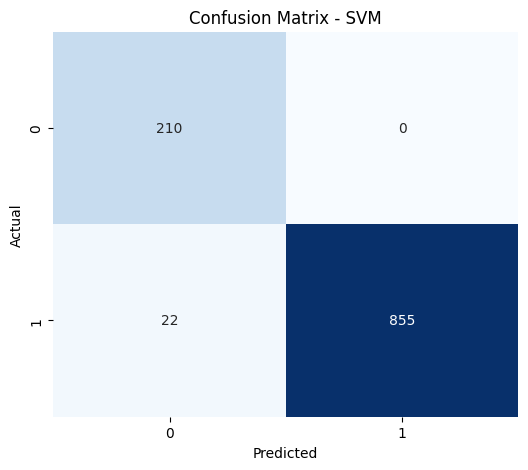

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()


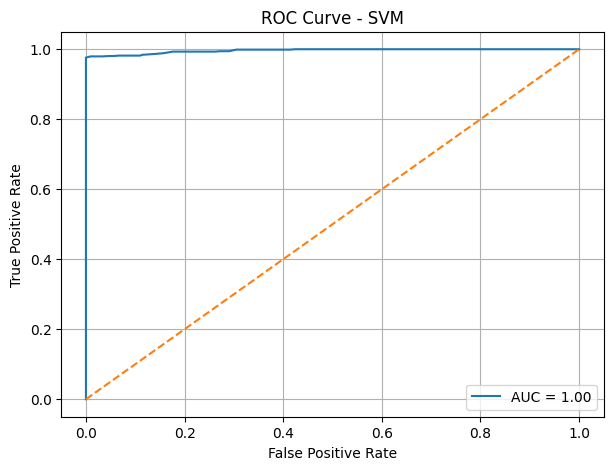

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.grid()
plt.show()


In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc = []
fold_auc = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    X_tr_sm, y_tr_sm = SMOTE(random_state=42).fit_resample(X_tr, y_tr)

    svm_model.fit(X_tr_sm, y_tr_sm)

    y_pred = svm_model.predict(X_te)
    y_proba = svm_model.predict_proba(X_te)[:, 1]

    fold_acc.append(accuracy_score(y_te, y_pred))
    fold_auc.append(roc_auc_score(y_te, y_proba))

    print(f"Fold {fold}: Accuracy={fold_acc[-1]:.4f}, AUC={fold_auc[-1]:.4f}")

print("Mean Accuracy:", np.mean(fold_acc))
print("Mean AUC:", np.mean(fold_auc))


Fold 1: Accuracy=0.9761, AUC=0.9935
Fold 2: Accuracy=0.9706, AUC=0.9929
Fold 3: Accuracy=0.9825, AUC=0.9954
Fold 4: Accuracy=0.9788, AUC=0.9965
Fold 5: Accuracy=0.9825, AUC=0.9938
Mean Accuracy: 0.9781016567808744
Mean AUC: 0.9944193309660193


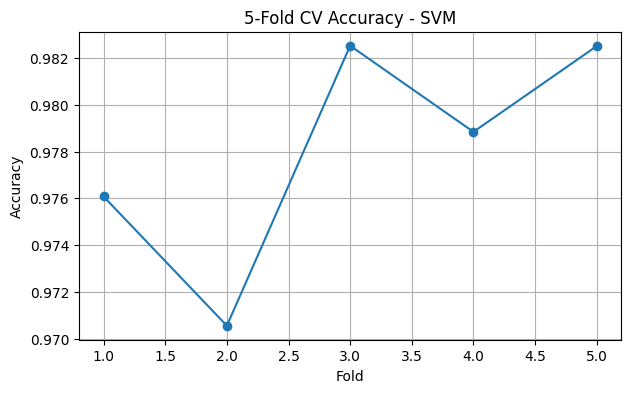

In [13]:
plt.figure(figsize=(7,4))
plt.plot(range(1,6), fold_acc, marker='o')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold CV Accuracy - SVM")
plt.grid()
plt.show()


# **Naive Bayes (GaussianNB)**

In [14]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_sm, y_train_sm)

y_pred = nb_model.predict(X_test)
y_pred_proba = nb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7709291628334867
              precision    recall  f1-score   support

           0       0.46      1.00      0.63       210
           1       1.00      0.72      0.83       877

    accuracy                           0.77      1087
   macro avg       0.73      0.86      0.73      1087
weighted avg       0.90      0.77      0.79      1087



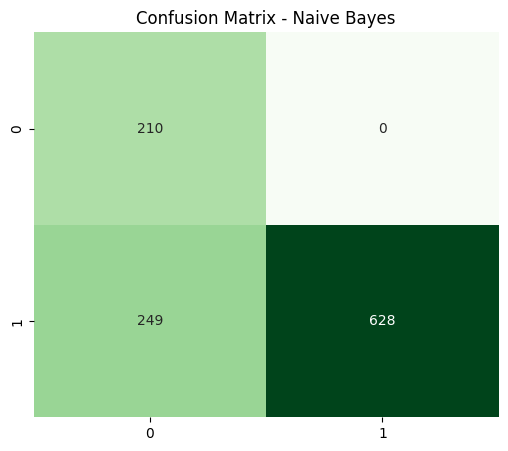

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Confusion Matrix - Naive Bayes")
plt.show()


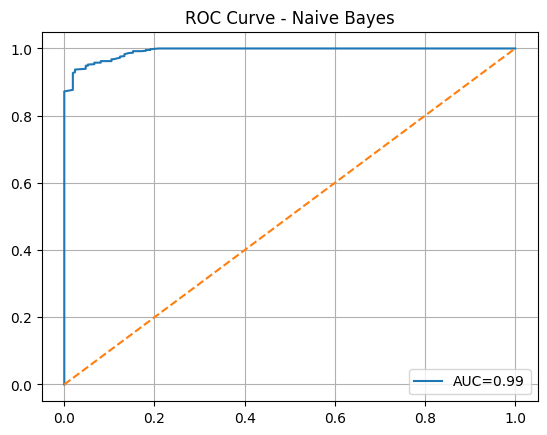

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Naive Bayes")
plt.legend()
plt.grid()
plt.show()


Fold 1: Accuracy=0.7672
Fold 2: Accuracy=0.7259
Fold 3: Accuracy=0.7397
Fold 4: Accuracy=0.7452
Fold 5: Accuracy=0.7551


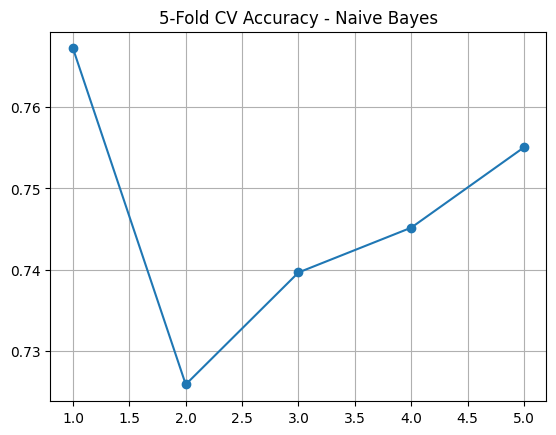

In [17]:
fold_acc = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    X_tr_sm, y_tr_sm = SMOTE(random_state=42).fit_resample(X_tr, y_tr)

    nb_model.fit(X_tr_sm, y_tr_sm)
    y_pred = nb_model.predict(X_te)

    fold_acc.append(accuracy_score(y_te, y_pred))
    print(f"Fold {fold}: Accuracy={fold_acc[-1]:.4f}")

plt.plot(range(1,6), fold_acc, marker='o')
plt.title("5-Fold CV Accuracy - Naive Bayes")
plt.grid()
plt.show()


# **XGBoost**

In [32]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_sm, y_train_sm)

y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9806807727690893
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       210
           1       1.00      0.98      0.99       877

    accuracy                           0.98      1087
   macro avg       0.95      0.99      0.97      1087
weighted avg       0.98      0.98      0.98      1087



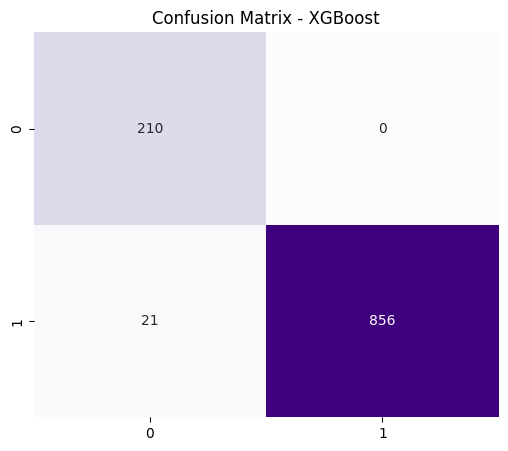

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title("Confusion Matrix - XGBoost")
plt.show()

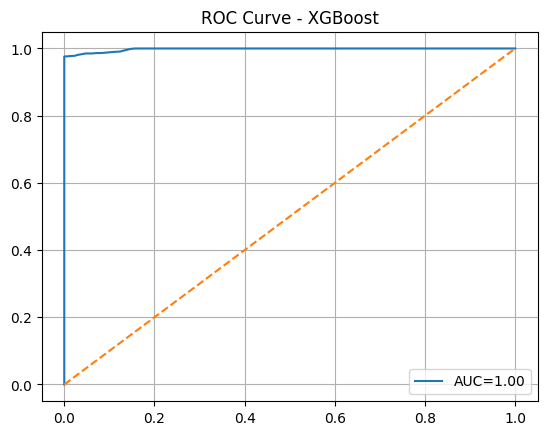

In [25]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid()
plt.show()


Fold 1: Accuracy=0.9770
Fold 2: Accuracy=0.9761
Fold 3: Accuracy=0.9844
Fold 4: Accuracy=0.9816
Fold 5: Accuracy=0.9825


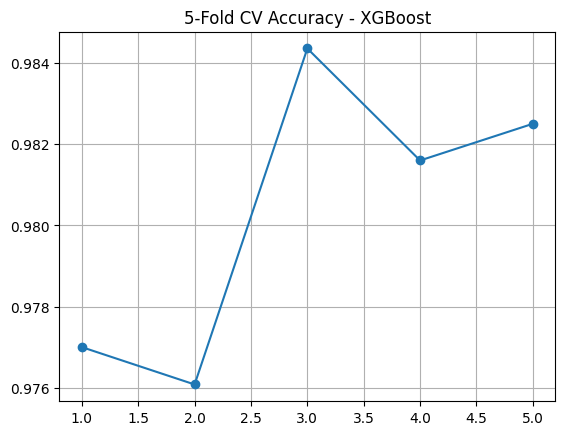

In [28]:
fold_acc = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    X_tr_sm, y_tr_sm = SMOTE(random_state=42).fit_resample(X_tr, y_tr)

    xgb_model.fit(X_tr_sm, y_tr_sm)
    y_pred = xgb_model.predict(X_te)

    fold_acc.append(accuracy_score(y_te, y_pred))
    print(f"Fold {fold}: Accuracy={fold_acc[-1]:.4f}")

plt.plot(range(1,6), fold_acc, marker='o')
plt.title("5-Fold CV Accuracy - XGBoost")
plt.grid()
plt.show()


# **AdaBoost**

In [37]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

ada_model.fit(X_train_sm, y_train_sm)
y_pred = ada_model.predict(X_test)
y_pred_proba = ada_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accuracy: 0.9438822447102115
              precision    recall  f1-score   support

           0       0.80      0.95      0.87       210
           1       0.99      0.94      0.96       877

    accuracy                           0.94      1087
   macro avg       0.89      0.95      0.92      1087
weighted avg       0.95      0.94      0.95      1087



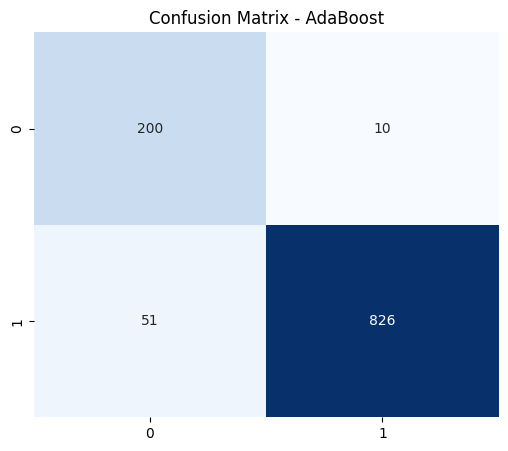

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - AdaBoost")
plt.show()

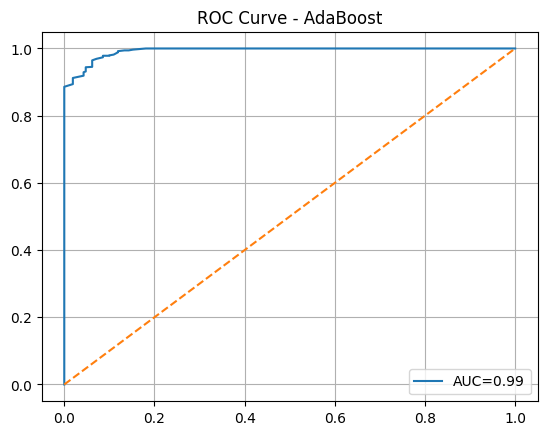

In [39]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - AdaBoost")
plt.legend()
plt.grid()
plt.show()


Fold 1: Accuracy=0.9503
Fold 2: Accuracy=0.9439
Fold 3: Accuracy=0.9374
Fold 4: Accuracy=0.9457
Fold 5: Accuracy=0.9337


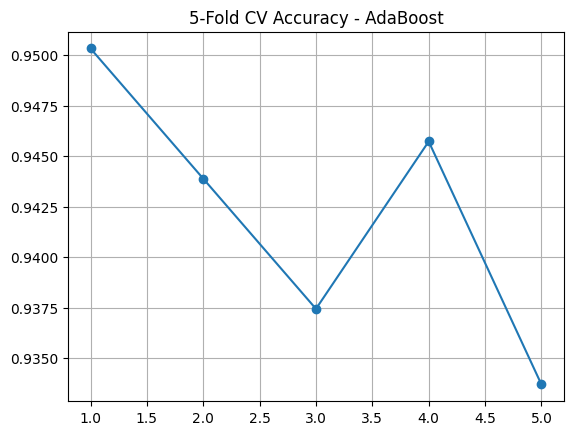

In [42]:
fold_acc = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    X_tr_sm, y_tr_sm = SMOTE(random_state=42).fit_resample(X_tr, y_tr)

    ada_model.fit(X_tr_sm, y_tr_sm)
    y_pred = ada_model.predict(X_te)

    fold_acc.append(accuracy_score(y_te, y_pred))
    print(f"Fold {fold}: Accuracy={fold_acc[-1]:.4f}")

plt.plot(range(1,6), fold_acc, marker='o')
plt.title("5-Fold CV Accuracy - AdaBoost")
plt.grid()
plt.show()


# **LightGBM**

In [43]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

lgbm_model.fit(X_train_sm, y_train_sm)
y_pred = lgbm_model.predict(X_test)
y_pred_proba = lgbm_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3506, number of negative: 3506
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001283 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 28
[LightGBM] [Info] Number of data points in the train set: 7012, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy: 0.9806807727690893
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       210
           1       1.00      0.98      0.99       877

    accuracy                           0.98      1087
   macro avg       0.95      0.99      0.97      1087
weighted avg       0.98      0.98      0.98      1087



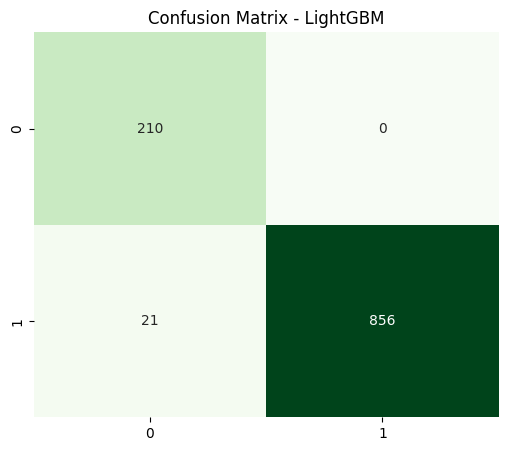

In [45]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Confusion Matrix - LightGBM")
plt.show()

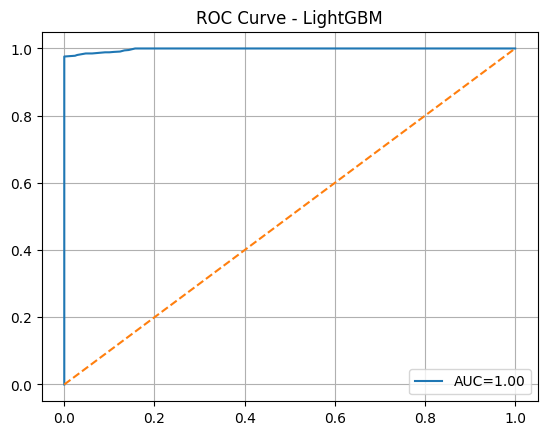

In [46]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - LightGBM")
plt.legend()
plt.grid()
plt.show()


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3506, number of negative: 3506
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001617 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 28
[LightGBM] [Info] Number of data points in the train set: 7012, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Fold 1: Accuracy=0.9798
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3506, number of negative: 3506
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total

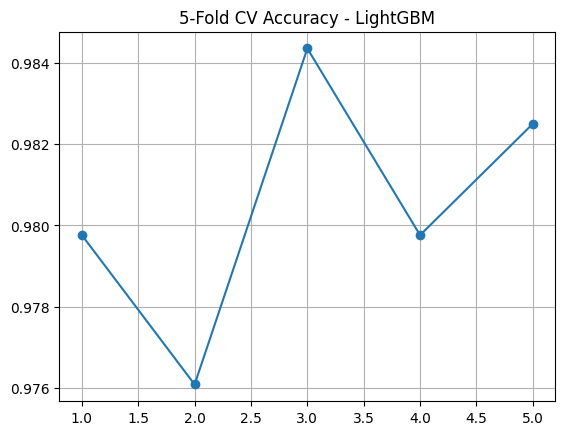

In [47]:
fold_acc = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    X_tr_sm, y_tr_sm = SMOTE(random_state=42).fit_resample(X_tr, y_tr)

    lgbm_model.fit(X_tr_sm, y_tr_sm)
    y_pred = lgbm_model.predict(X_te)

    fold_acc.append(accuracy_score(y_te, y_pred))
    print(f"Fold {fold}: Accuracy={fold_acc[-1]:.4f}")

plt.plot(range(1,6), fold_acc, marker='o')
plt.title("5-Fold CV Accuracy - LightGBM")
plt.grid()
plt.show()


# **LOGISTIC REGRESSION**

In [48]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_sm, y_train_sm)

y_pred = log_model.predict(X_test)
y_pred_proba = log_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9503219871205152

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.94      0.88       210
           1       0.98      0.95      0.97       877

    accuracy                           0.95      1087
   macro avg       0.91      0.95      0.92      1087
weighted avg       0.95      0.95      0.95      1087



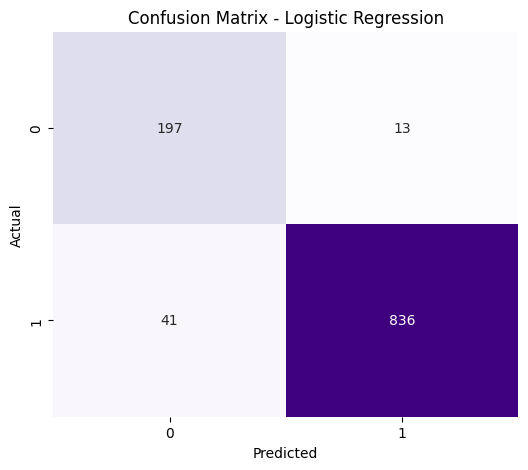

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


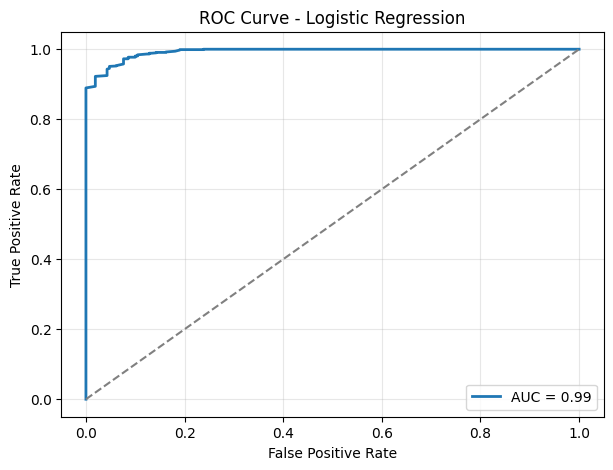

In [50]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


Fold 1: Accuracy=0.9531
Fold 2: Accuracy=0.9512
Fold 3: Accuracy=0.9393
Fold 4: Accuracy=0.9503
Fold 5: Accuracy=0.9411


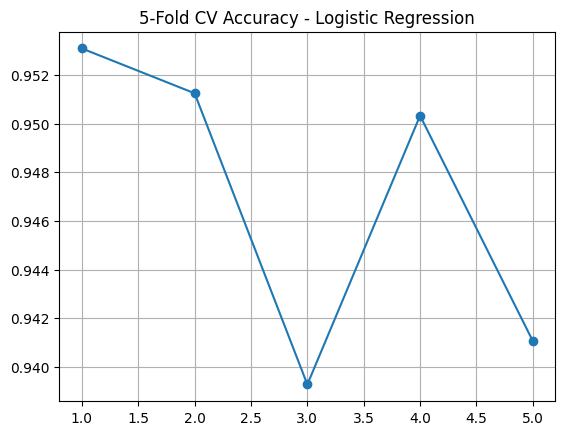

In [51]:
fold_acc = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    X_tr_sm, y_tr_sm = SMOTE(random_state=42).fit_resample(X_tr, y_tr)

    log_model.fit(X_tr_sm, y_tr_sm)
    y_pred = log_model.predict(X_te)

    fold_acc.append(accuracy_score(y_te, y_pred))
    print(f"Fold {fold}: Accuracy={fold_acc[-1]:.4f}")

plt.plot(range(1,6), fold_acc, marker='o')
plt.title("5-Fold CV Accuracy - Logistic Regression")
plt.grid()
plt.show()


### **Deep Learning models**

# **MLP**

In [52]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_model.fit(X_train_sm, y_train_sm)

y_pred = mlp_model.predict(X_test)
y_pred_proba = mlp_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9797608095676172

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95       210
           1       1.00      0.97      0.99       877

    accuracy                           0.98      1087
   macro avg       0.95      0.99      0.97      1087
weighted avg       0.98      0.98      0.98      1087



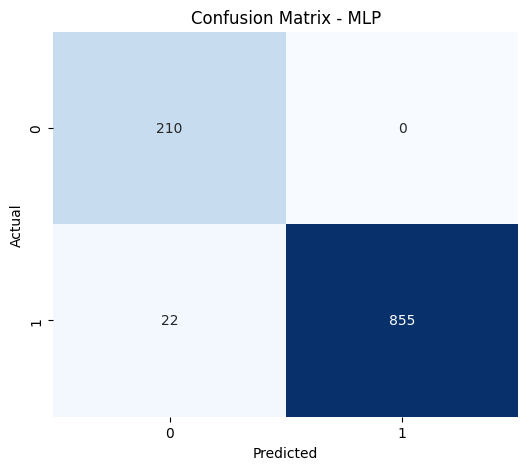

In [54]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MLP")
plt.show()


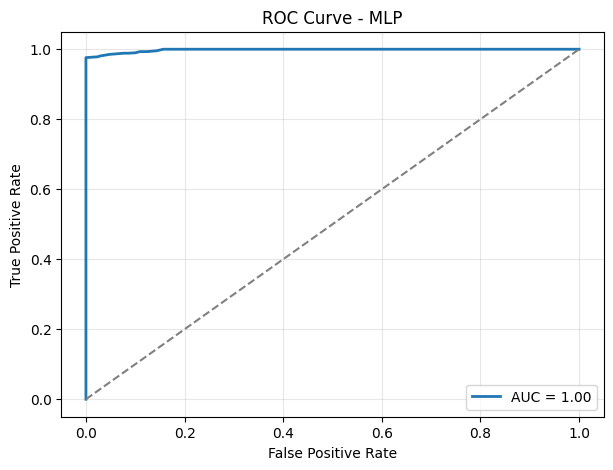

In [55]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


Fold 1: Accuracy=0.9788
Fold 2: Accuracy=0.9761
Fold 3: Accuracy=0.9844
Fold 4: Accuracy=0.9798
Fold 5: Accuracy=0.9825


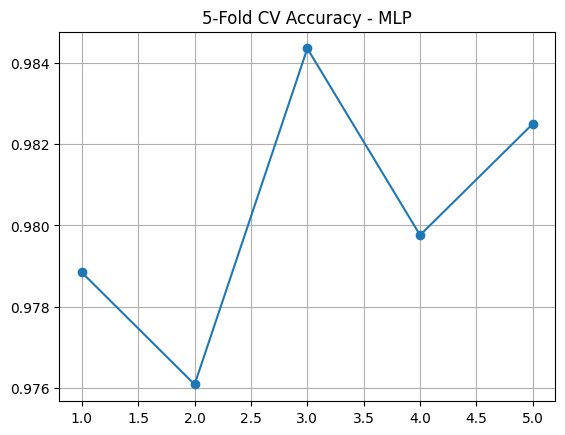

In [56]:
fold_acc = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    X_tr_sm, y_tr_sm = SMOTE(random_state=42).fit_resample(X_tr, y_tr)

    mlp_model.fit(X_tr_sm, y_tr_sm)
    y_pred = mlp_model.predict(X_te)

    fold_acc.append(accuracy_score(y_te, y_pred))
    print(f"Fold {fold}: Accuracy={fold_acc[-1]:.4f}")

plt.plot(range(1,6), fold_acc, marker='o')
plt.title("5-Fold CV Accuracy - MLP")
plt.grid()
plt.show()


# **DNN**

In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def build_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_sm.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [58]:
dnn_model = build_dnn()

dnn_model.fit(
    X_train_sm, y_train_sm,
    epochs=30,
    batch_size=32,
    verbose=0
)

y_pred_proba = dnn_model.predict(X_test).ravel()
y_pred = (y_pred_proba > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.9806807727690893

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95       210
           1       1.00      0.98      0.99       877

    accuracy                           0.98      1087
   macro avg       0.95      0.99      0.97      1087
weighted avg       0.98      0.98      0.98      1087



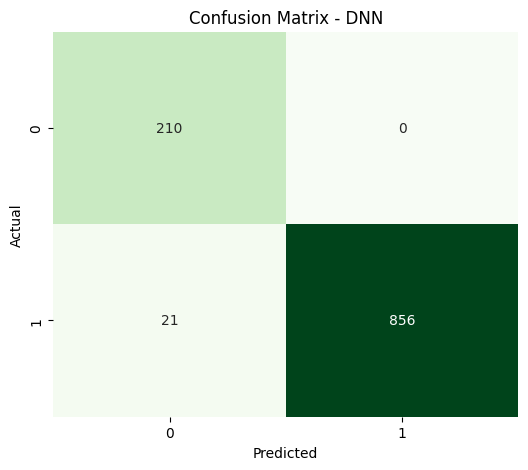

In [60]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DNN")
plt.show()


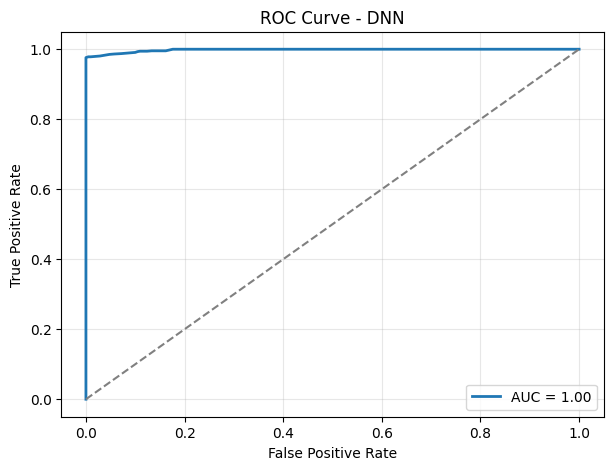

In [61]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DNN")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 1: Accuracy=0.9798


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 2: Accuracy=0.9761


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 3: Accuracy=0.9844


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 4: Accuracy=0.9779


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 5: Accuracy=0.9825


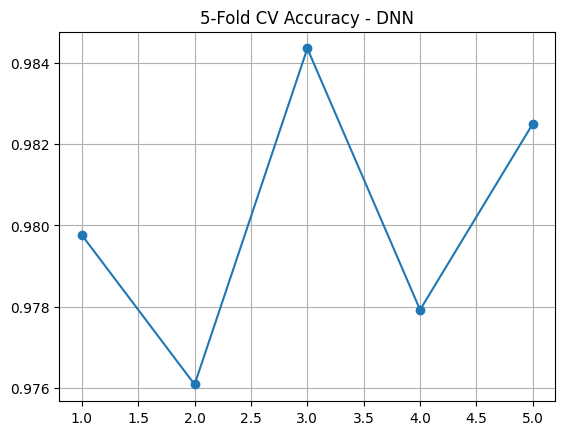

In [63]:
fold_acc = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    X_tr_sm, y_tr_sm = SMOTE(random_state=42).fit_resample(X_tr, y_tr)

    # Re-initialize the DNN model for each fold to prevent data leakage
    dnn_model = build_dnn()

    dnn_model.fit(
        X_tr_sm, y_tr_sm,
        epochs=30,
        batch_size=32,
        verbose=0
    )

    y_pred_proba = dnn_model.predict(X_te).ravel()
    # Convert probabilities to binary predictions (0 or 1)
    y_pred = (y_pred_proba > 0.5).astype(int)

    fold_acc.append(accuracy_score(y_te, y_pred))
    print(f"Fold {fold}: Accuracy={fold_acc[-1]:.4f}")

plt.plot(range(1,6), fold_acc, marker='o')
plt.title("5-Fold CV Accuracy - DNN")
plt.grid()
plt.show()

# **ML DL Ensemble**

### **Soft Voting (Probability Averaging) → safest & cleanest**

Although individual models achieved high accuracy, an ensemble model was constructed using soft voting to reduce variance and improve generalization.
The ensemble integrates neural networks and gradient-boosting classifiers, capturing both linear and non-linear decision boundaries.

In [65]:
# Assume all models already trained on X_train_sm, y_train_sm

models = {
    "mlp": mlp_model,
    "svm": svm_model,             # must be probability=True
    "xgb": xgb_model,
    "lgbm": lgbm_model
}


In [66]:
probas = []

# MLP
probas.append(mlp_model.predict_proba(X_test)[:, 1])

# SVM
probas.append(svm_model.predict_proba(X_test)[:, 1])

# XGBoost
probas.append(xgb_model.predict_proba(X_test)[:, 1])

# LightGBM
probas.append(lgbm_model.predict_proba(X_test)[:, 1])



In [67]:
ensemble_proba = np.mean(probas, axis=0)
ensemble_pred = (ensemble_proba > 0.5).astype(int)


In [68]:
print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_pred))
print("\nClassification Report:\n",
      classification_report(y_test, ensemble_pred))

roc_auc = roc_auc_score(y_test, ensemble_proba)
print("Ensemble ROC-AUC:", roc_auc)


Ensemble Accuracy: 0.9806807727690893

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95       210
           1       1.00      0.98      0.99       877

    accuracy                           0.98      1087
   macro avg       0.95      0.99      0.97      1087
weighted avg       0.98      0.98      0.98      1087

Ensemble ROC-AUC: 0.9981837432806646


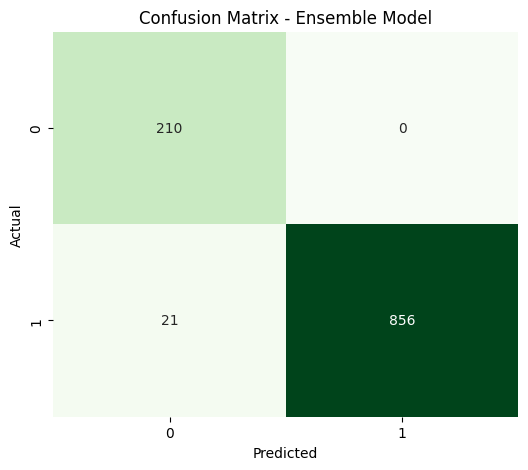

In [69]:
cm = confusion_matrix(y_test, ensemble_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Confusion Matrix - Ensemble Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


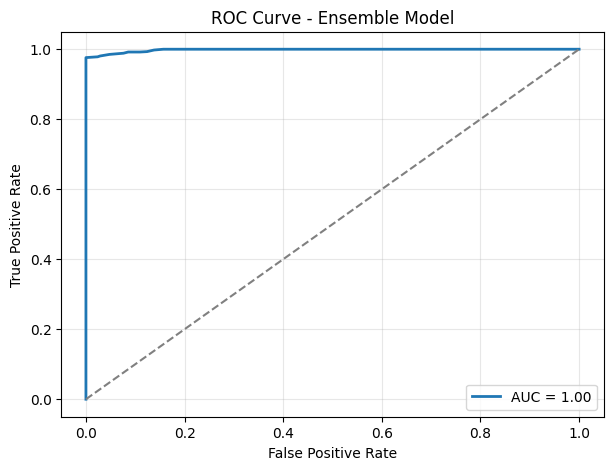

In [70]:
fpr, tpr, _ = roc_curve(y_test, ensemble_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.title("ROC Curve - Ensemble Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
